## Loading packages

In [1]:
import os
# 1. 限制线程与强制确定性 (旧版 Torch 的杀手锏)
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 
os.environ["R_HOME"] = "/home/bio/miniconda3/envs/spCLUE/lib/R"


In [2]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import sys

warnings.filterwarnings("ignore")


spCLUE_ROOT_PATH = "/home/bio/lhz/spCLUE"
sys.path.append(spCLUE_ROOT_PATH)
import spCLUE

spCLUE.fix_seed(0)

## Loading data

In [3]:
sample_name="151671"
# ========== 1. 处理数据 ==========
adata = spCLUE.load_and_preprocess_st(data_path="../dataset/DLPFC/151671/")

--- 正在从 ../dataset/DLPFC/151671/ 加载数据 ---
原始数据维度: 4110 spots, 33538 genes
✅ 标签合并成功！
--- 执行过滤、归一化与缩放 ---
--- 使用 sklearn 进行 200 维全量基因 PCA 降维 (可能需要十几秒) ---
✅ 预处理完成！用于训练的 X_pca 维度: (4110, 200)


In [4]:
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
print(adata)

AnnData object with n_obs × n_vars = 4110 × 21631
    obs: 'in_tissue', 'array_row', 'array_col', 'barcode', 'sample_name', 'tissue', 'row', 'col', 'imagerow', 'imagecol', 'Cluster', 'height', 'width', 'sum_umi', 'sum_gene', 'subject', 'position', 'replicate', 'subject_position', 'discard', 'key', 'cell_count', 'SNN_k50_k4', 'SNN_k50_k5', 'SNN_k50_k6', 'SNN_k50_k7', 'SNN_k50_k8', 'SNN_k50_k9', 'SNN_k50_k10', 'SNN_k50_k11', 'SNN_k50_k12', 'SNN_k50_k13', 'SNN_k50_k14', 'SNN_k50_k15', 'SNN_k50_k16', 'SNN_k50_k17', 'SNN_k50_k18', 'SNN_k50_k19', 'SNN_k50_k20', 'SNN_k50_k21', 'SNN_k50_k22', 'SNN_k50_k23', 'SNN_k50_k24', 'SNN_k50_k25', 'SNN_k50_k26', 'SNN_k50_k27', 'SNN_k50_k28', 'GraphBased', 'Maynard', 'Martinowich', 'Layer', 'Region', 'layer_guess_reordered', 'layer_guess_reordered_short', 'expr_chrM', 'expr_chrM_ratio', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 

In [5]:
g_spatia = spCLUE.prepare_graph(adata, "spatial")
g_expr = spCLUE.prepare_graph(adata, "expr")
graph_dict = {"spatial": g_spatia, "expr":g_expr}

create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<


## train spCLUE

In [6]:
spCLUE_model = spCLUE.spCLUE(adata.obsm["X_pca"], graph_dict, n_clusters)
_, adata.obsm["spCLUE"] = spCLUE_model.train()

Training Start =========================>


 20%|████████████████▏                                                                 | 99/500 [00:02<00:10, 38.86it/s]

epoch 100: 0.5852210346131436


In [7]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [8]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151671: 0.7436855094255659


## visualization

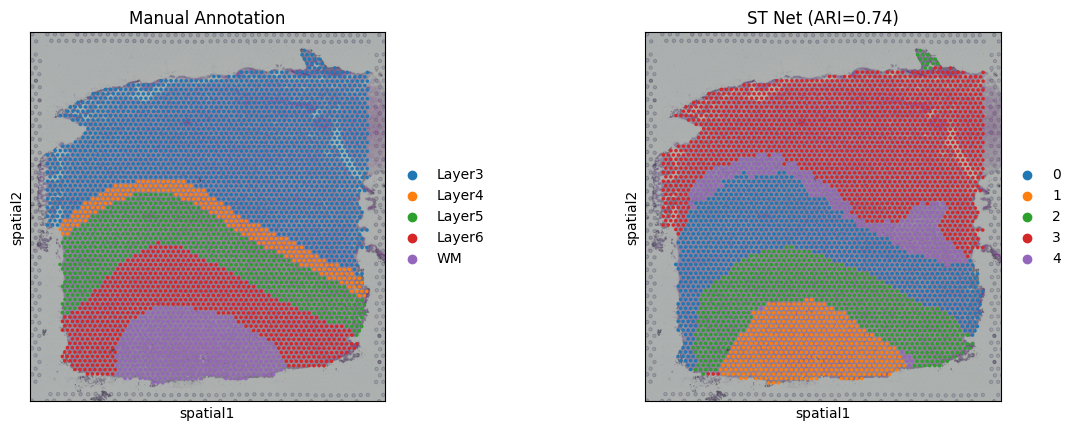

In [9]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
# sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"ST Net (ARI={round(ARI, 2)})"])
sc.pl.spatial(
    adata, 
    color=["Region", "spCLUE"], 
    title=["Manual Annotation", f"ST Net (ARI={round(ARI, 2)})"],
    show=True,        # 设置为 False，不在行间直接显示（可选）
    save="_spatial_results.png"  # 文件名后缀，Scanpy 会自动前缀 "spatial"
)